# Clasificación de Flores Iris con Árboles de Decisión

*En* este cuaderno, exploraremos el uso de **Árboles de Decisión** para clasificar flores. Utilizaremos el famoso **dataset Iris**, que contiene medidas de diferentes especies de flores Iris, para construir un modelo capaz de predecir la especie de una flor basándose en sus características físicas.

![decisión](https://drive.google.com/uc?export=download&id=1QG7B6f3rBriaXanIvuOss2rmk3RCRag2)

El objetivo de este algoritmo es crear una especie de árbol que sea capaz de predecir lo más aproximadamente posible en qué categoría caerán los nuevos datos que ingresen al modelo.

Veamos cómo crear un árbol de decisión directamente con un ejemplo.

Comencemos importando todas las librerías que vamos a necesitar para nuestro ejercicio.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Vamos a cargar una base de datos de ejemplo de Seaborn, que se llama "*iris*".

In [ ]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

Y así es como podemos ver que existen *3 especies* de flores Iris: **setosa**, **versicolor** y **virginica**.

Lo que quiero hacer ahora, es **entrenar un modelo** de Machine Learning, para que cuando encontremos una nueva flor, se pueda fijar en las características de sus sépalos y de sus pétalos, para definir de qué especie se trata. Y como este problema que quiero resolver implica anticipar una categoría, me vendría muy bien hacerlo con un **árbol de decisión**.

Para hacer árboles de decisión también tenemos que crear **conjuntos de entrenamiento y de prueba**, y luego entrenar al modelo, así que vamos por partes.

Primero vamos a definir las variables dependientes e independientes.

Las **variables independientes** son todos los datos de los pétalos y los sépalos. Entonces:

In [ ]:
X= df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


Fíjate que con `df.tail()` vemos las últimas filas del dataset, que corresponden a la especie *virginica* (mientras que con `df.head()` solo habíamos visto ejemplos de *setosa*).

La **variable dependiente**, que es la que quiero averiguar, es la columna `species`.

Pero aquí tenemos un problema: esa columna contiene *strings* (ya que cada registro contiene las palabras "*setosa*", "*versicolor*" o "*virginica*"), por lo tanto tenemos que codificar esos valores para transformarlos en valores numéricos con los cuales el algoritmo pueda hacer sus cálculos.

Para eso, voy a usar una herramienta de Sci-kit Learn que se llama `LabelEncoder()` y que hemos importado al inicio de este cuaderno.

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df["species"])
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

El resultado ha sido un **array** que ha reemplazado los nombres de las especies por los valores **0**, **1**, o **2**, según corresponda, para cada uno de los 150 registros existentes en `df`.

Con esta transformación hecha, puedo definir la variable dependiente `y`.

Ahora que tengo ambas variables, el paso siguiente es separar todos mis registros en **grupos de entrenamiento** y **grupos de prueba**, tal como hemos hecho hasta ahora:

In [ ]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X,
                                                           y,
                                                           train_size=0.8,
                                                           random_state=42)

El parámetro `random_state` sirve para controlar la aleatoriedad con que se distribuyen los registros durante la división entre entrenamiento y prueba. Al proporcionar un número entero cualquiera a `random_state`, te aseguras que los resultados sean reproducibles; es decir, cada vez que se ejecute el código con ese mismo número, la división de los datos será siempre la misma.

Esto es útil para experimentos que necesitan ser reproducibles por ti o por otros, o cuando se está ajustando un modelo y se quiere que la división de los datos permanezca constante para comparar el rendimiento de diferentes parámetros del modelo. Siempre que pongas el mismo número entero, los registros se van a dividir de igual manera.

Ahora vamos a crear el objeto que contenga al modelo del **Árbol de Decisión**, al cual también hemos importado a este cuaderno.

Por la misma razón, más abajo también le vamos a fijar un `random_state` al propio `DecisionTreeClassifier`: aunque no cambia *qué* aprende el árbol, sí evita que haya pequeñas variaciones al desempatar entre cortes igual de buenos, para que el resultado sea siempre reproducible.

In [ ]:
arbol = DecisionTreeClassifier()

Y procedemos a **entrenar** al modelo:

In [ ]:
arbol.fit(X_entrena, y_entrena)

DecisionTreeClassifier()

Nuestro modelo ya está entrenado, por lo que estamos en condiciones de dibujar nuestro árbol. Para eso vamos a usar una herramienta de Sci-kit Learn que se llama `plot_tree`.

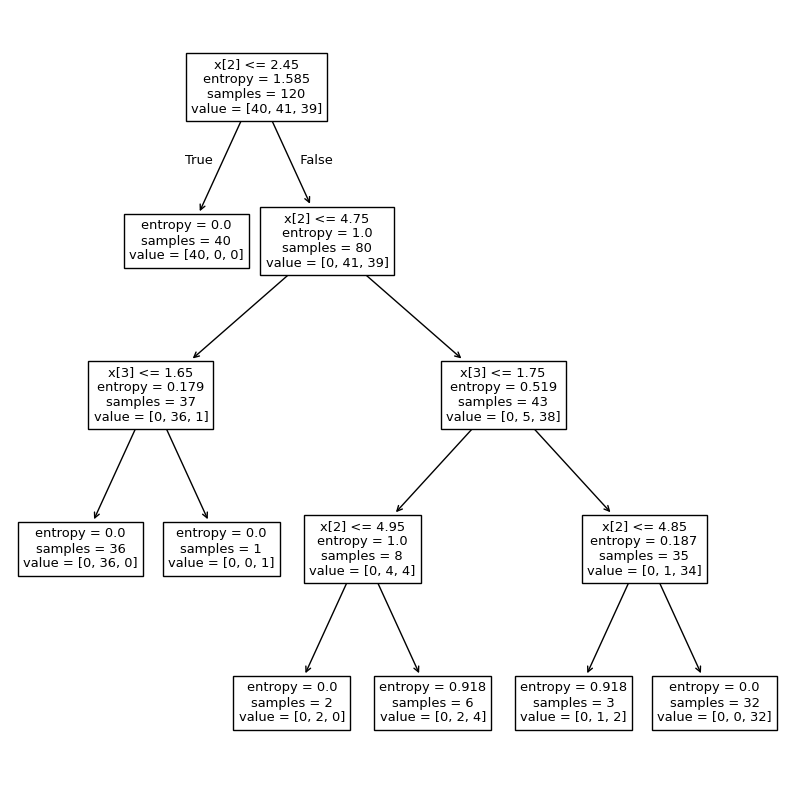

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(decision_tree=arbol);

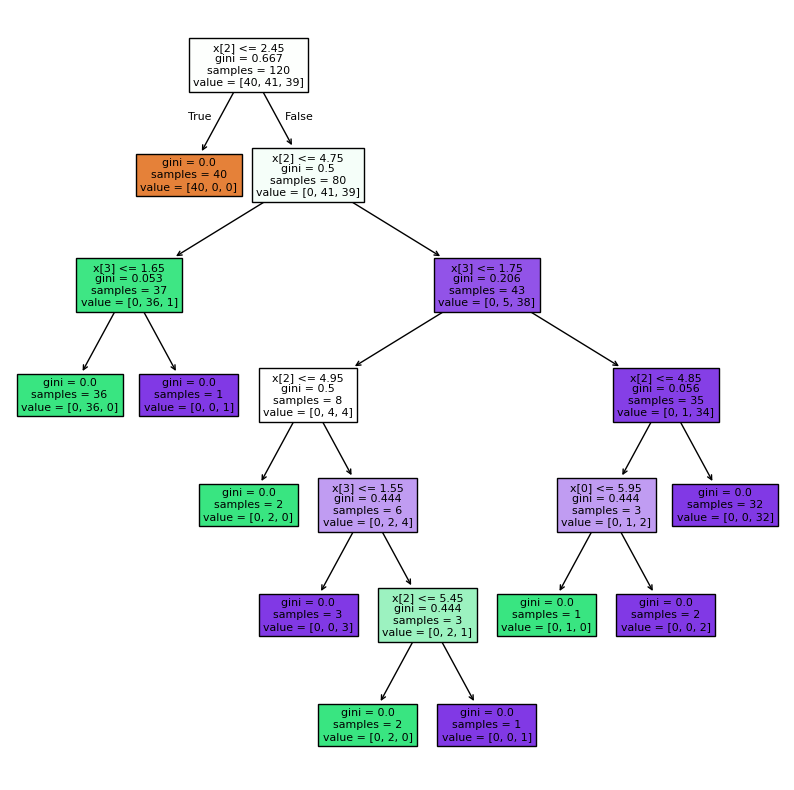

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(decision_tree=arbol,
         filled=True);

Podemos ajustar el tamaño de la letra con `fontsize=8`, para que sea más prolijo y fácil de leer:

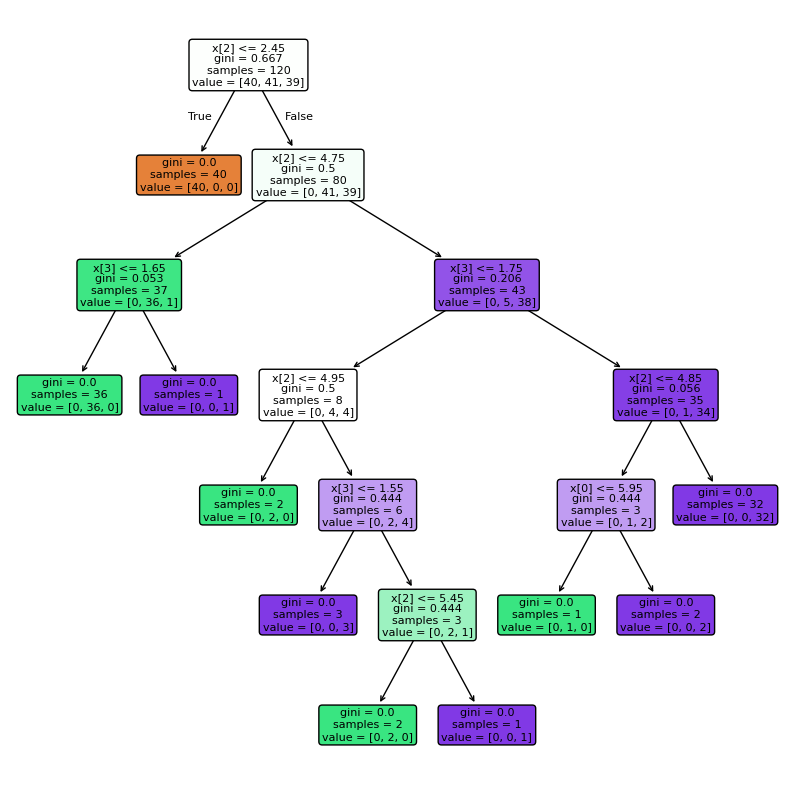

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(decision_tree=arbol,
          filled=True,
          rounded=True,
          fontsize=8);

Con estos colores vamos a poder diferenciar las especies, pero no estaría de más que también podamos leer sus nombres.

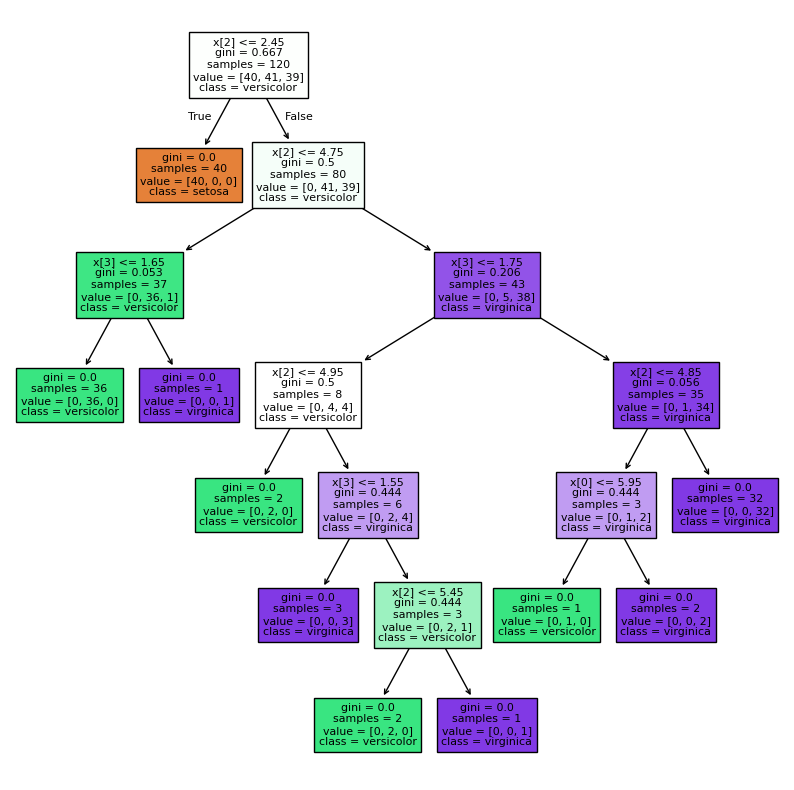

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(decision_tree=arbol,
          class_names=["setosa", "versicolor", "virginica"],
          filled=True);

Y lo más importante, es que podamos ver al comienzo de cada recuadro, cuál es la decisión que ha tomado en ese punto para dividir los datos, para lo cual sería bueno contar con los nombres de las columnas que se han usado. Eso lo hacemos así:

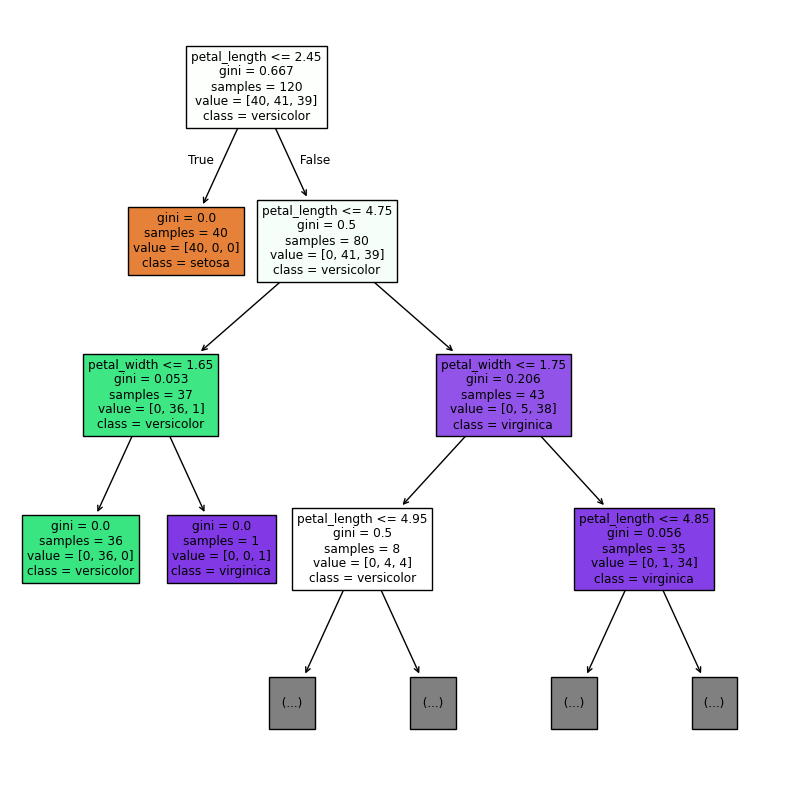

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(decision_tree=arbol,
          class_names=["setosa", "versicolor", "virginica"],
          feature_names = df.columns.to_list(),max_depth=3,
          filled=True);

Un detalle importante: el `max_depth=3` que acabamos de usar es un parámetro de **`plot_tree`**, y solo limita cuántos niveles se *dibujan*. El árbol que entrenamos (`arbol`) no tiene ningún límite de profundidad — sigue siendo el mismo modelo completo de antes, simplemente estamos recortando la imagen para poder leerla. Más adelante en este cuaderno vamos a ver qué pasa cuando limitamos de verdad la profundidad del *modelo*.

Ahora sí, nuestro árbol está presentable, y podemos comenzar a interpretar los descubrimientos que ha hecho Machine Learning aquí.


### Interpretación de los Árboles de Decisión

La historia que este gráfico nos cuenta es la siguiente: el modelo ha identificado, que la mejor forma de comenzar a hacerse preguntas para clasificar a nuestras flores, es preguntarnos si el largo de su pétalo es igual o menor a **2.45**, ya que si es así, es áltamente probable que se trate de una flor de la especie *setosa*.

`gini = 0.667`: El coeficiente de Gini mide la impureza del nodo, y por lo tanto qué tan confiable es. Si tuviera un valor de **0** indicaría que es un nodo perfectamente puro (y que todas las muestras en el nodo son de una sola clase). En este caso tenemos un valor de **0.667**, lo cual indica cierto nivel de mezcla de clases en este nodo.

`samples = 120`: Esto indica cuántas muestras han pasado por este nodo. Ya que este es el nodo raíz, naturalmente las 120 muestras del conjunto pasaron por este nodo.

`value = [40, 41, 39]`: Este array muestra cuántas muestras de cada clase están presentes en este nodo. La primera posición del array corresponde a la primera clase ('*setosa*'), la segunda posición a la segunda clase ('*versicolor*'), y la tercera a la tercera clase ('*virginica*'). Así que hay 40 muestras de '*setosa*', 41 de '*versicolor*' y 39 de '*virginica*'.

`class = versicolor`: Este es el resultado de la clasificación en este nodo. Dado que '*versicolor*' es la clase con más muestras en este nodo (aunque por un margen muy pequeño), cualquier muestra que llegue a este punto y no se divida más será clasificada como '*versicolor*'.

En el recuadro que sale hacia la izquierda tenemos 40 muestras que cumplieron con la condición de tener un largo de pétalo igual o menor a *2.45*, de las cuales todas corresponden a la especie setosa, y como puedes ver, este nodo tiene un gini de **0**, por lo tanto es absolutamente confiable.

Las otras 80 muestras cayeron en un nuevo nodo, donde Machine Learning ha identificado que el mejor paso para seguir clasificando las flores es verificando si el largo de sus pétalos es menor o igual a **4.75**. Si esto es así o no, va a ir distribuyendo a cada caso a lo largo de una serie de nuevas preguntas, hasta identificar a qué especies pertenecen.

Como puedes ver, cada una de las hojas finales de nuestro árbol tienen un gini perfecto, por lo que podemos confiar en que nuestro modelo ha aprendido a clasificar las flores de iris con absoluta precisión, y que si el día de mañana traemos una nueva flor y el modelo nos dice que es *versicolor*, tenemos que confiar en que ha acertado.

Este nivel de perfección se debe a que hemos usado una base de datos ficticia y muy controlada. En la vida real es muy difícil encontrar estos niveles de precisión, sino que tendremos que ir definiendo cuáles son los umbrales de confianza que estableceremos para nuestros modelos según el caso.


# Predicciones y métricas de evaluación

In [ ]:
y_pred = arbol.predict(X_prueba)
score = accuracy_score(y_prueba, y_pred)
print(f"Precisión (accuracy): {score:.2f}")

Precisión (accuracy): 1.00


### Precisión (Accuracy)

La precisión (accuracy) es una de las métricas más simples y comunes para evaluar modelos de clasificación. Se calcula como la proporción de predicciones correctas sobre el total de predicciones. Un valor de 1.00 (o 100%) indica que el modelo hizo todas sus predicciones correctamente en el conjunto de prueba.

$$Accuracy = \frac{\text{Número de predicciones correctas}}{\text{Número total de predicciones}}$$

# Matriz de confusión

In [ ]:
print("Matriz de Confusión:")
matriz = confusion_matrix(y_prueba, y_pred)
print(matriz)


Matriz de Confusión:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


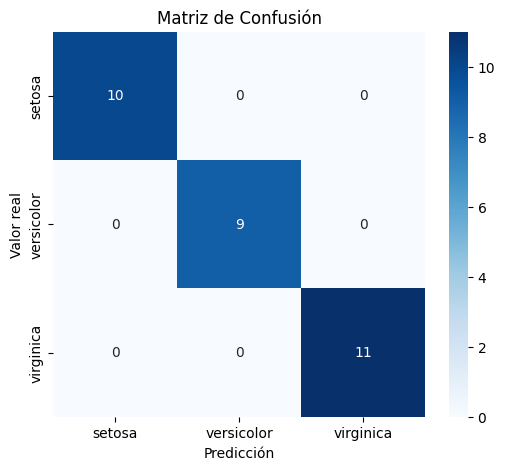

In [ ]:
etiquetas = ["setosa", "versicolor", "virginica"]

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

### Matriz de Confusión

La matriz de confusión es una tabla que resume el rendimiento de un algoritmo de clasificación en un conjunto de datos de prueba. Permite visualizar el rendimiento del algoritmo, mostrando cuántas predicciones fueron correctas e incorrectas, y cómo se distribuyen estas. Cada fila de la matriz representa las instancias en una clase real, mientras que cada columna representa las instancias en una clase predicha.

-   **Verdaderos Positivos (VP)**: Observaciones que son positivas y se predijeron como positivas.
-   **Verdaderos Negativos (VN)**: Observaciones que son negativas y se predijeron como negativas.
-   **Falsos Positivos (FP)**: Observaciones que son negativas pero se predijeron como positivas (error de Tipo I).
-   **Falsos Negativos (FN)**: Observaciones que son positivas pero se predijeron como negativas (error de Tipo II).

En la matriz mostrada, los valores en la diagonal (10, 9, 11) representan las predicciones correctas para cada especie. Por ejemplo, se predijeron correctamente 10 'setosa' cuando eran realmente 'setosa'. Los valores fuera de la diagonal son 0, lo que indica que no hubo errores de clasificación en este conjunto de prueba, lo cual es excepcional.

# Reporte de clasificación

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_prueba, y_pred, target_names=["setosa", "versicolor", "virginica"]))


Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Reporte de Clasificación

El reporte de clasificación es un resumen detallado de las métricas de rendimiento del modelo por cada clase. Incluye:

-   **Precisión (Precision)**: La proporción de identificaciones positivas que fueron realmente correctas. Es la habilidad del clasificador de no etiquetar como positiva una muestra que era negativa.
    
    $$Precision = \frac{VP}{VP + FP}$$

-   **Exhaustividad (Recall)**: La proporción de positivos reales que fueron identificados correctamente. Es la habilidad del clasificador de encontrar todas las muestras positivas.
    
    $$Recall = \frac{VP}{VP + FN}$$

-   **Puntuación F1 (F1-Score)**: Es la media armónica de la precisión y la exhaustividad. Ofrece un equilibrio entre ambas métricas.
    
    $$F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

-   **Soporte (Support)**: Es el número de ocurrencias reales de la clase en el conjunto de datos de prueba.

En este caso, todas las métricas son 1.00 para cada clase, lo que refuerza la idea de un modelo con una clasificación perfecta en el conjunto de prueba.

A modo de ejemplo -y para entender **por qué no conviene hacerlo**- vamos a calcular métricas propias de regresión sobre nuestras predicciones de clasificación, usando el mismo conjunto de prueba que venimos usando:

## Hiperparámetros y Sobreajuste (Overfitting)

El árbol que entrenamos al principio (`DecisionTreeClassifier(random_state=42)`) no tenía **ningún límite de profundidad**, así que creció hasta que todas sus hojas quedaron perfectamente puras (`gini = 0`). Por eso logró un *accuracy* de 1.00 tanto en el conjunto de prueba: el dataset de *iris* es muy fácil de separar, pero en un problema real esta falta de límites casi siempre termina en **sobreajuste** (el árbol memoriza el ruido del set de entrenamiento y generaliza peor a datos nuevos).

Los hiperparámetros más importantes para controlar esto son:

- **`max_depth`**: la profundidad máxima permitida del árbol.
- **`min_samples_leaf`**: la cantidad mínima de muestras que debe tener una hoja.
- **`min_samples_split`**: la cantidad mínima de muestras necesarias para dividir un nodo.
- **`criterion`**: el criterio de partición (`"gini"` o `"entropy"`).

Vamos a entrenar varios árboles con distinta `max_depth` y comparar el *accuracy* en entrenamiento contra el de prueba, para ver el efecto en la práctica.

In [ ]:
profundidades = range(1, 11)
accuracy_entrena = []
accuracy_prueba = []

for profundidad in profundidades:
    arbol_prof = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    arbol_prof.fit(X_entrena, y_entrena)
    accuracy_entrena.append(accuracy_score(y_entrena, arbol_prof.predict(X_entrena)))
    accuracy_prueba.append(accuracy_score(y_prueba, arbol_prof.predict(X_prueba)))

for p, a_ent, a_pru in zip(profundidades, accuracy_entrena, accuracy_prueba):
    print(f"max_depth={p:>2}  |  accuracy entrenamiento={a_ent:.2f}  |  accuracy prueba={a_pru:.2f}")

max_depth= 1  |  accuracy entrenamiento=0.68  |  accuracy prueba=0.63
max_depth= 2  |  accuracy entrenamiento=0.95  |  accuracy prueba=0.97
max_depth= 3  |  accuracy entrenamiento=0.96  |  accuracy prueba=1.00
max_depth= 4  |  accuracy entrenamiento=0.97  |  accuracy prueba=1.00
max_depth= 5  |  accuracy entrenamiento=0.99  |  accuracy prueba=1.00
max_depth= 6  |  accuracy entrenamiento=1.00  |  accuracy prueba=1.00
max_depth= 7  |  accuracy entrenamiento=1.00  |  accuracy prueba=1.00
max_depth= 8  |  accuracy entrenamiento=1.00  |  accuracy prueba=1.00
max_depth= 9  |  accuracy entrenamiento=1.00  |  accuracy prueba=1.00
max_depth=10  |  accuracy entrenamiento=1.00  |  accuracy prueba=1.00


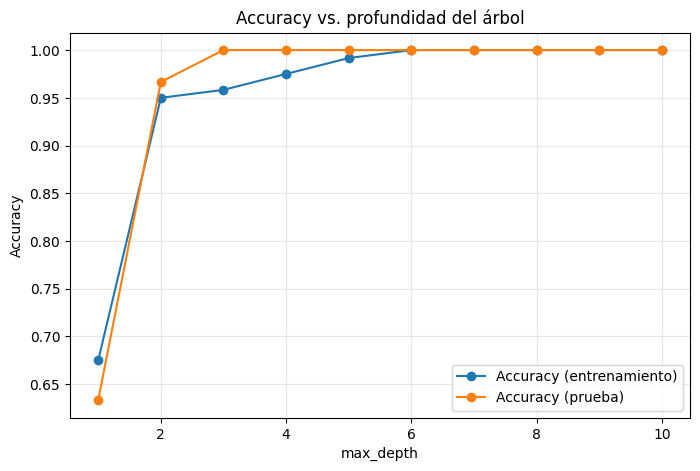

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), accuracy_entrena, marker="o", label="Accuracy (entrenamiento)")
plt.plot(list(profundidades), accuracy_prueba, marker="o", label="Accuracy (prueba)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. profundidad del árbol")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Como *iris* es un dataset chico y muy bien separado, en este caso particular el *accuracy* de prueba se mantiene alto incluso con profundidades bajas, y no se ve una caída dramática por sobreajuste. Aun así, el gráfico muestra la idea clave: a partir de cierta profundidad, el modelo ya no gana nada nuevo en el conjunto de prueba, aunque siga "aprendiendo" más detalles del conjunto de entrenamiento. En datasets más ruidosos o complejos, esa brecha entre ambas curvas suele ser mucho más marcada, y es la señal de que conviene limitar `max_depth` (o podar el árbol con `ccp_alpha`) en lugar de dejarlo crecer libremente.

## Importancia de las Variables (Feature Importances)

Los árboles de decisión también nos permiten ver qué tan importante fue cada variable a la hora de armar las divisiones. Esto se calcula en base a cuánto reduce cada variable la impureza (Gini) en promedio, y está disponible en el atributo `feature_importances_` del modelo ya entrenado.

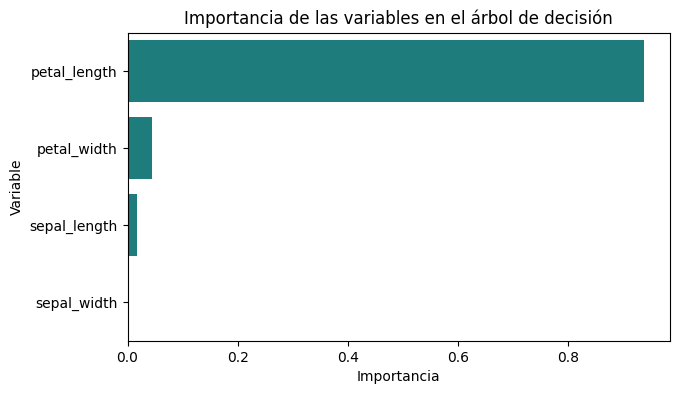

,0
petal_length,0.938435
petal_width,0.044286
sepal_length,0.017279
sepal_width,0.000000


In [ ]:
importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importancias.values, y=importancias.index, color="#0F8B8D")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables en el árbol de decisión")
plt.show()

importancias

Como era de esperar, las variables relacionadas con el **pétalo** (`petal_length` y `petal_width`) son las que más aportan para distinguir entre especies, mientras que las del **sépalo** aportan mucho menos. Esto coincide con lo que vimos en el propio dibujo del árbol, donde la primera pregunta (la más importante) ya usaba `petal_length`.

## Prediciendo una Flor Nueva

Por último, veamos cómo se usa el modelo ya entrenado para clasificar una flor que no está en el dataset. Alcanza con armar un `DataFrame` con las mismas columnas que usamos para entrenar (`X`), y usar `le.inverse_transform()` para traducir la predicción numérica de vuelta a un nombre de especie.

In [ ]:
flor_nueva = pd.DataFrame([
    {
    "sepal_length": 5.8,
    "sepal_width": 2.7,
    "petal_length": 4.1,
    "petal_width": 1.0,
}
])
prediccion = arbol.predict(flor_nueva)
especie_predicha = le.inverse_transform(prediccion)

print(f"El modelo predice que esta flor es: {especie_predicha[0]}")

El modelo predice que esta flor es: versicolor


## Para Practicar

Antes de pasar a las conclusiones, te proponemos algunos ejercicios para reforzar lo aprendido. Podés agregar celdas nuevas debajo de esta para resolverlos:

1. **Cambiá `max_depth`** en la celda donde creamos `arbol` (al principio del cuaderno) por distintos valores fijos (por ejemplo `2`, `4` o `6`) y volvé a correr todo el cuaderno. ¿Cambia el *accuracy* de prueba? ¿Cambia el dibujo del árbol?
2. **Probá con `criterion="entropy"`** en lugar de `"gini"` al crear el `DecisionTreeClassifier`. ¿El árbol resultante hace las mismas preguntas, en el mismo orden?
3. **Repetí el análisis de `max_depth` vs. accuracy** (la sección de Hiperparámetros y Sobreajuste) pero usando `min_samples_leaf` en lugar de `max_depth`, probando valores como `1, 5, 10, 20`.
4. **Cambiá los valores de `flor_nueva`** por otras medidas y fijate si el modelo predice una especie distinta. ¿Qué combinación de medidas te da una *virginica*? ¿Y una *versicolor*?
5. **Desafío:** repetí este mismo flujo de trabajo completo (entrenar, visualizar, evaluar) pero con otro dataset de clasificación de Seaborn o Scikit-learn, por ejemplo `sns.load_dataset("penguins")` (vas a necesitar eliminar filas con valores nulos con `dropna()` antes de entrenar).

## Conclusiones

En este cuaderno aprendimos a:

- Entrenar un **Árbol de Decisión** de clasificación con Scikit-learn (`DecisionTreeClassifier`), separando los datos en conjuntos de entrenamiento y de prueba con `train_test_split`.
- **Codificar** una variable categórica (`species`) a valores numéricos con `LabelEncoder`, y volver a traducirlos con `inverse_transform`.
- **Visualizar e interpretar** el árbol con `plot_tree`, entendiendo qué significan `gini`, `samples`, `value` y `class` en cada nodo.
- **Evaluar** el modelo con las métricas propias de clasificación: *accuracy*, matriz de confusión y reporte de clasificación (precision, recall, F1-score) -y por qué métricas de regresión como MAE/MSE/RMSE *no* son adecuadas aquí.
- Controlar la complejidad del árbol con **hiperparámetros** como `max_depth`, y por qué es importante para evitar el **sobreajuste**.
- Leer la **importancia de las variables** (`feature_importances_`) para entender en qué se basó el modelo.

En la próxima clase vamos a construir sobre estas mismas ideas para ver los **Bosques Aleatorios (Random Forest)**, que combinan muchos árboles de decisión para lograr predicciones más robustas.